<a href="https://colab.research.google.com/github/Karthikreddy1010/MicroscopicPlastic-Semantic-segmentation/blob/main/experiment_B_loss_function_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXPERIMENT B — CONTROLLED LOSS-FUNCTION EXPERIMENT

**Purpose:** Determine whether the segmentation loss function is limiting foreground
segmentation performance in the proposed model — **EfficientNetV2-B3 + MRFM +
Stage-Adaptive Attention**.

**Architecture:** IDENTICAL to `ablation_4_full_proposed_model` (EfficientNetV2-B3
backbone, MRFM, Edge/Coordinate/Channel-Spatial stage-adaptive attention, encoder,
decoder, skip connections, feature dimensions, layer counts, activations,
normalization). No architecture changes whatsoever.

**The ONLY experimental variable is the loss function.**

- **Control loss (baseline, unchanged):** Phase 1 = `aggressive_imbalance_loss`
  (5.0·Dice + 3.0·Tversky[α=0.7,β=0.3] + 1.0·Focal[α=0.75,γ=2.0]); Phase 2 =
  `focal_dice_loss` (3.0·Dice + 1.0·Focal[α=0.75,γ=2.0]).
- **Experimental loss (new, this notebook):** `tversky_focal_dice_loss` = 1.0·Tversky
  [α=0.3, β=0.7] + 1.0·Focal[α=0.75, γ=2.0] + 1.0·Dice, used identically in both
  Phase 1 and Phase 2 (never silently reverts to the control loss).

Everything else — dataset (556/100/100 fixed split), preprocessing, 512×512
resolution, augmentation, optimizers, learning rates, batch size, epoch budgets,
early stopping / ReduceLROnPlateau, checkpoint methodology, validation-only
threshold selection (`np.linspace(0.1, 0.7, 13)`), and metric definitions — is kept
byte-for-byte identical to the reproducibility experiment, and is re-run for
**seeds 42, 123, 2024**.

Results are compared against the frozen 3-seed baseline:

```
Dice           = 0.7873 ± 0.0014
Foreground IoU = 0.6492 ± 0.0019
mIoU           = 0.8206 ± 0.0010
Precision      = 0.7581 ± 0.0072
Recall         = 0.8189 ± 0.0090
```


In [ ]:
!unzip /content/archive.zip


In [ ]:
!pip install tensorflow

In [2]:
import os
import random
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns
from scipy import stats
import pandas as pd
from skimage.transform import rotate, resize
import warnings
warnings.filterwarnings('ignore')


# Confirm GPU
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    print(" GPU detected:", gpus)
    # Enable memory growth
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

    # Enable mixed precision
    mixed_precision.set_global_policy('mixed_float16')
    print(" Mixed precision enabled")
else:
    print(" No GPU detected - running on CPU")


def set_all_seeds(seed):
    """Set every random source used by the pipeline (IDENTICAL handling to the
    existing 3-seed reproducibility experiment): Python random, NumPy, TensorFlow.
    Dataset shuffling and augmentation randomness both draw from these global
    generators, so this single call fixes them as well."""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


# Configuration - MUST MATCH ABLATIONS 1-3 / the reproducibility experiment.
# This is a LOSS-ONLY experiment: resolution, batch size, and epoch budgets are
# unchanged.
IMG_HEIGHT = 512
IMG_WIDTH = 512
BATCH_SIZE = 4
EPOCHS = 100
PATIENCE = 15

# Paths to your data (verified working paths from ablation_efficientnetv2b3_baseline.ipynb)
TRAIN_IMAGE_DIR = '/content/training/training/Training_original'
TRAIN_MASK_DIR = '/content/training/training/Finalmasks'
VAL_IMAGE_DIR = '/content/val/val/Original'
VAL_MASK_DIR = '/content/val/val/val_100masks'
TEST_IMAGE_DIR = '/content/Testing/Testing/Original'
TEST_MASK_DIR = '/content/Testing/Testing/testing_100masks'

# Fixed 3-seed protocol for Experiment B
SEEDS = [42, 123, 2024]

print(f"Configuration:")
print(f"  Image size: {IMG_HEIGHT} x {IMG_WIDTH}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs (Phase 2 ceiling): {EPOCHS}")
print(f"  Patience: {PATIENCE}")
print(f"  Seeds: {SEEDS}")


 GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
 Mixed precision enabled
Configuration:
  Image size: 512 x 512
  Batch size: 4
  Max epochs (Phase 2 ceiling): 100
  Patience: 15
  Seeds: [42, 123, 2024]


In [3]:
# ============================================================================
# DATA LOADING & PREPROCESSING (IDENTICAL TO ABLATIONS 1-3 / ablation_4)
# ============================================================================

def normalize_name(name):
    """Normalize filename for matching."""
    name = os.path.basename(name)
    name = os.path.splitext(name)[0]
    name = name.replace('_mask', '')
    return name


def preprocess_mask(mask):
    """Proper mask binarization."""
    mask_binary = (mask > 127).astype(np.float32)
    return mask_binary


def calculate_iou(y_true, y_pred):
    """Calculate Intersection over Union for binary masks."""
    y_true = y_true.flatten().astype(np.uint8)
    y_pred = y_pred.flatten().astype(np.uint8)

    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection

    if union == 0:
        return 0.0

    return intersection / union


def calculate_miou(y_true, y_pred):
    """Calculate mean Intersection over Union for both classes."""
    y_true = y_true.flatten().astype(np.uint8)
    y_pred = y_pred.flatten().astype(np.uint8)

    iou_class_0 = calculate_iou(1 - y_true, 1 - y_pred)  # Background
    iou_class_1 = calculate_iou(y_true, y_pred)           # Foreground

    miou = (iou_class_0 + iou_class_1) / 2.0

    return {
        'iou_background': iou_class_0,
        'iou_foreground': iou_class_1,
        'miou': miou
    }


def calculate_iou_metric(y_true, y_pred):
    """
    Calculate standard IoU (Intersection over Union) metric.
    """
    y_true_flat = y_true.flatten().astype(np.uint8)
    y_pred_flat = y_pred.flatten().astype(np.uint8)

    intersection = np.sum(y_true_flat * y_pred_flat)
    union = np.sum(y_true_flat) + np.sum(y_pred_flat) - intersection

    if union == 0:
        return 1.0 if intersection == 0 else 0.0

    iou = intersection / union
    return iou


def calculate_iou_per_image(y_true, y_pred):
    """Calculate IoU for each image individually."""
    ious = []
    for i in range(len(y_true)):
        gt = y_true[i].flatten().astype(np.uint8)
        pred = y_pred[i].flatten().astype(np.uint8)

        intersection = np.sum(gt * pred)
        union = np.sum(gt) + np.sum(pred) - intersection

        if union == 0:
            iou = 1.0 if intersection == 0 else 0.0
        else:
            iou = intersection / union
        ious.append(iou)

    return np.array(ious)


def calculate_comprehensive_iou_metrics(y_true, y_pred):
    """Calculate comprehensive IoU metrics."""
    y_true_flat = y_true.flatten().astype(np.uint8)
    y_pred_flat = y_pred.flatten().astype(np.uint8)

    iou_bg = calculate_iou(1 - y_true_flat, 1 - y_pred_flat)
    iou_fg = calculate_iou(y_true_flat, y_pred_flat)
    miou = (iou_bg + iou_fg) / 2.0

    iou_standard = calculate_iou_metric(y_true, y_pred)
    per_image_ious = calculate_iou_per_image(y_true, y_pred)

    return {
        'iou': iou_standard,
        'iou_background': iou_bg,
        'iou_foreground': iou_fg,
        'miou': miou,
        'iou_mean': np.mean(per_image_ious),
        'iou_std': np.std(per_image_ious),
        'iou_median': np.median(per_image_ious),
        'iou_min': np.min(per_image_ious),
        'iou_max': np.max(per_image_ious),
        'per_image_ious': per_image_ious
    }


def calculate_segmentation_metrics(y_true, y_pred_binary):
    """Calculate pixel-wise segmentation metrics."""
    y_true_flat = y_true.flatten().astype(np.uint8)
    y_pred_flat = y_pred_binary.flatten().astype(np.uint8)

    precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
    recall = recall_score(y_true_flat, y_pred_flat, zero_division=0)
    f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)

    intersection = np.sum(y_true_flat * y_pred_flat)
    dice = (2. * intersection) / (np.sum(y_true_flat) + np.sum(y_pred_flat) + 1e-8)

    iou_metrics = calculate_comprehensive_iou_metrics(y_true, y_pred_binary)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'dice': dice,
        'iou': iou_metrics['iou'],
        'iou_background': iou_metrics['iou_background'],
        'iou_foreground': iou_metrics['iou_foreground'],
        'miou': iou_metrics['miou'],
        'iou_mean': iou_metrics['iou_mean'],
        'iou_std': iou_metrics['iou_std'],
        'iou_median': iou_metrics['iou_median'],
        'iou_min': iou_metrics['iou_min'],
        'iou_max': iou_metrics['iou_max']
    }


print(" Utility functions defined")


 Utility functions defined


In [4]:
# ============================================================================
# AUGMENTATION PIPELINE (IDENTICAL TO ABLATIONS 1-3)
# ============================================================================

def augment_geometric_numpy(image, mask, seed=None):
    """Apply geometric augmentations (rotation, zoom, flip) with consistent randomness."""
    if hasattr(image, 'numpy'):
        image = image.numpy()
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()

    image = np.asarray(image, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    if seed is not None:
        np.random.seed(seed)

    h, w = image.shape[:2]

    # Random rotation
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-15, 15)
        image = rotate(image, angle, mode='reflect', preserve_range=True)
        mask = rotate(mask, angle, mode='reflect', preserve_range=True)

    # Random zoom
    if np.random.rand() < 0.5:
        zoom_factor = np.random.uniform(0.9, 1.1)
        new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)

        image_zoomed = resize(image, (new_h, new_w), preserve_range=True, anti_aliasing=True)
        mask_zoomed = resize(mask, (new_h, new_w), preserve_range=True, anti_aliasing=False, order=0)

        if zoom_factor > 1.0:
            start_h = (new_h - h) // 2
            start_w = (new_w - w) // 2
            image = image_zoomed[start_h:start_h+h, start_w:start_w+w]
            mask = mask_zoomed[start_h:start_h+h, start_w:start_w+w]
        else:
            pad_h = (h - new_h) // 2
            pad_w = (w - new_w) // 2

            if len(mask_zoomed.shape) == 3:
                image = np.pad(image_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                              mode='reflect')
                mask = np.pad(mask_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                             mode='constant', constant_values=0)
            else:
                image = np.pad(image_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                              mode='reflect')
                mask = np.pad(mask_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w)),
                             mode='constant', constant_values=0)

    # Random horizontal flip
    if np.random.rand() < 0.5:
        image = np.fliplr(image)
        mask = np.fliplr(mask)

    # Random vertical flip
    if np.random.rand() < 0.5:
        image = np.flipud(image)
        mask = np.flipud(mask)

    if len(mask.shape) == 2:
        mask = np.expand_dims(mask, axis=-1)

    return image.astype(np.float32), mask.astype(np.float32)


def augment_photometric_numpy(image, seed=None):
    """Apply photometric augmentations to image only."""
    if hasattr(image, 'numpy'):
        image = image.numpy()

    image = np.asarray(image, dtype=np.float32)

    if seed is not None:
        np.random.seed(seed)

    brightness = np.random.uniform(-0.05, 0.05)
    image = image + brightness

    contrast = np.random.uniform(0.95, 1.05)
    mean = image.mean()
    image = (image - mean) * contrast + mean

    gamma = np.random.uniform(0.95, 1.05)
    image = np.power(np.clip(image, 0, 1), gamma)

    noise = np.random.normal(0, 0.005, image.shape).astype(np.float32)
    image = image + noise

    image = np.clip(image, 0, 1)

    return image.astype(np.float32)


def augment_combined_numpy(image, mask):
    """Combined augmentation pipeline."""
    if hasattr(image, 'numpy'):
        image = image.numpy()
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()

    image = np.asarray(image, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    seed = np.random.randint(0, 10000)

    image, mask = augment_geometric_numpy(image, mask, seed=seed)
    image = augment_photometric_numpy(image, seed=seed+100)

    return image, mask


print(" Augmentation functions defined")



 Augmentation functions defined


In [5]:
# ============================================================================
# DATA LOADING (IDENTICAL TO ABLATIONS 1-3)
# ============================================================================

def load_data_raw(image_dir, mask_dir):
    """Load RAW data without preprocessing - returns [0, 1] range."""
    print(f"Loading RAW data from: {image_dir}")

    if not os.path.exists(image_dir):
        raise ValueError(f"Image directory does not exist: {image_dir}")

    if not os.path.exists(mask_dir):
        raise ValueError(f"Mask directory does not exist: {mask_dir}")

    image_paths = sorted([
        os.path.join(image_dir, fname)
        for fname in os.listdir(image_dir)
        if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    print(f"Found {len(image_paths)} images")

    images = []
    masks = []

    for img_idx, img_path in enumerate(image_paths):
        fname = os.path.basename(img_path)
        fname_key = normalize_name(fname)

        mask_found = False
        mask_path = None

        mask_candidate = os.path.join(mask_dir, fname_key + '_mask.png')
        if os.path.exists(mask_candidate):
            mask_path = mask_candidate
            mask_found = True

        if not mask_found:
            for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
                mask_candidate = os.path.join(mask_dir, fname_key + ext)
                if os.path.exists(mask_candidate):
                    mask_path = mask_candidate
                    mask_found = True
                    break

        if not mask_found:
            base_name = os.path.splitext(fname)[0]
            for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
                mask_candidate = os.path.join(mask_dir, base_name + ext)
                if os.path.exists(mask_candidate):
                    mask_path = mask_candidate
                    mask_found = True
                    break

        if not mask_found or mask_path is None:
            if img_idx < 5:
                print(f"Warning: No mask found for {fname_key}")
            continue

        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize((IMG_WIDTH, IMG_HEIGHT), Image.BILINEAR)
            img_array = np.array(img, dtype=np.float32) / 255.0

            mask = Image.open(mask_path).convert('L')
            mask = mask.resize((IMG_WIDTH, IMG_HEIGHT), Image.NEAREST)
            mask_array = np.array(mask, dtype=np.float32)
            mask_array = preprocess_mask(mask_array)
            mask_array = np.expand_dims(mask_array, axis=-1)

            images.append(img_array)
            masks.append(mask_array)

            if img_idx < 3:
                print(f"  Loaded: {fname_key} -> shape: {img_array.shape}")

        except Exception as e:
            print(f"Error loading {fname}: {e}")
            continue

    if len(images) == 0:
        raise ValueError(f"No valid images loaded from {image_dir}")

    images = np.array(images, dtype=np.float32)
    masks = np.array(masks, dtype=np.float32)

    print(f"\nSuccessfully loaded {len(images)} images")
    print(f"Image shape: {images.shape}")
    print(f"Image range: [{images.min():.4f}, {images.max():.4f}]")
    print(f"Mask shape: {masks.shape}")

    return images, masks


def create_augmented_dataset_with_preprocessing(images, masks, batch_size, augment=True, shuffle=True):
    """Create tf.data.Dataset with augmentation THEN preprocessing."""

    def preprocess_for_efficientnet(img, mask):
        img = img * 255.0
        img = preprocess_input(img)
        return img, mask

    dataset = tf.data.Dataset.from_tensor_slices((images, masks))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(images), reshuffle_each_iteration=True)

    if augment:
        def augment_fn(img, mask):
            img, mask = tf.py_function(
                func=augment_combined_numpy,
                inp=[img, mask],
                Tout=[tf.float32, tf.float32]
            )
            img.set_shape([IMG_HEIGHT, IMG_WIDTH, 3])
            mask.set_shape([IMG_HEIGHT, IMG_WIDTH, 1])
            return img, mask

        dataset = dataset.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.map(preprocess_for_efficientnet, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


print("\n" + "="*80)
print("LOADING RAW DATA (NO PREPROCESSING YET)")
print("="*80)

X_train, y_train = load_data_raw(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR)
X_val, y_val = load_data_raw(VAL_IMAGE_DIR, VAL_MASK_DIR)
X_test, y_test = load_data_raw(TEST_IMAGE_DIR, TEST_MASK_DIR)

print(f"\nData shapes:")
print(f"Training:   X={X_train.shape}, y={y_train.shape}")
print(f"Validation: X={X_val.shape}, y={y_val.shape}")
print(f"Test:       X={X_test.shape}, y={y_test.shape}")

print("\n" + "="*80)
print("DATASET COUNT VERIFICATION")
print("="*80)
print(f"Training images: {len(X_train)}")
print(f"Training masks: {len(y_train)}")
print(f"Validation images: {len(X_val)}")
print(f"Validation masks: {len(y_val)}")
print(f"Test images: {len(X_test)}")
print(f"Test masks: {len(y_test)}")

if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
    raise ValueError("STOP: one or more splits loaded zero image-mask pairs. Check dataset paths.")

if X_train.shape[1:3] != (IMG_HEIGHT, IMG_WIDTH) or y_train.shape[1:3] != (IMG_HEIGHT, IMG_WIDTH):
    raise ValueError("STOP: image/mask dimensions do not match expected size.")

print(" Dataset counts and dimensions verified")

# Fixed split required by Experiment B (must match the reproducibility experiment)
EXPECTED_TRAIN_N, EXPECTED_VAL_N, EXPECTED_TEST_N = 556, 100, 100
if len(X_train) != EXPECTED_TRAIN_N or len(X_val) != EXPECTED_VAL_N or len(X_test) != EXPECTED_TEST_N:
    print(f" WARNING: split sizes ({len(X_train)}/{len(X_val)}/{len(X_test)}) do not match the "
          f"expected fixed split ({EXPECTED_TRAIN_N}/{EXPECTED_VAL_N}/{EXPECTED_TEST_N}). "
          f"Experiment B requires the EXACT same split as the baseline reproducibility experiment.")
else:
    print(f" Fixed split verified: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

print("=" * 80)
print(" NOTE: tf.data.Dataset objects (train/val/test) are (re)built inside the")
print(" per-seed training loop below via create_augmented_dataset_with_preprocessing(),")
print(" so that shuffling/augmentation randomness is correctly reseeded per seed.")
print(" The raw arrays X_train/y_train/X_val/y_val/X_test/y_test above are identical")
print(" across seeds and across the control experiment (dataset is NOT modified).")
print("=" * 80)



LOADING RAW DATA (NO PREPROCESSING YET)
Loading RAW data from: /content/training/training/Training_original
Found 556 images
  Loaded: 100_jpg.rf.f1b9d16649ab385e3691fa54301a3b61 -> shape: (512, 512, 3)
  Loaded: 106_jpg.rf.e8dc04354de3fadaea50922857adf45e -> shape: (512, 512, 3)
  Loaded: 10_jpg.rf.ecfa6fcdfec86c013936528ac959e40d -> shape: (512, 512, 3)

Successfully loaded 556 images
Image shape: (556, 512, 512, 3)
Image range: [0.0000, 1.0000]
Mask shape: (556, 512, 512, 1)
Loading RAW data from: /content/val/val/Original
Found 208 images
  Loaded: a--47-_jpg.rf.4b52f93a6fb94ded6e3a16355ccdf382 -> shape: (512, 512, 3)
  Loaded: a--54-_jpg.rf.0383febe7b193195524f26c0df25ea8c -> shape: (512, 512, 3)
  Loaded: a--56-_jpg.rf.b47891c3c1b3bdf692a27eed2ed119ab -> shape: (512, 512, 3)

Successfully loaded 100 images
Image shape: (100, 512, 512, 3)
Image range: [0.0000, 1.0000]
Mask shape: (100, 512, 512, 1)
Loading RAW data from: /content/Testing/Testing/Original
Found 200 images
  Loaded

In [6]:
# ============================================================================
# MODEL ARCHITECTURE: EfficientNetV2B3 + MRFM + STAGE-ADAPTIVE ATTENTION
# (COMPLETE PROPOSED MODEL)
# ============================================================================
# MRFM and Stage-Adaptive Attention (EdgeAttention / CoordinateAttention /
# ChannelSpatialAttention via MicroplasticAttention) implementations reused
# VERBATIM from the project source (final_microplastic_segmentation.ipynb),
# at the exact same encoder/decoder locations as the original proposed
# architecture. This is the ONLY architectural difference vs. Ablation 1:
# both MRFM and Stage-Adaptive Attention are present together.
# ============================================================================

def MRFM(x, filters, name):
    """
    Multi-Resolution Fusion Module
    Output channels = filters // 2

    Components:
      1. 3x3 convolution branch
      2. 5x5 convolution branch
      3. Dilated 3x3 convolution branch
      4. Concatenation of multi-resolution branches
      5. 1x1 convolution for feature compression
      6. Batch normalization
      7. Residual connection
    """
    out_ch = filters // 2
    shortcut = x

    # Branch 1: 3x3 convolution
    b3 = layers.Conv2D(filters, 3, padding='same',
                       kernel_initializer='he_normal',
                       name=f'{name}_b3')(x)
    b3 = layers.BatchNormalization(name=f'{name}_b3_bn')(b3)
    b3 = layers.Activation('relu', name=f'{name}_b3_relu')(b3)

    # Branch 2: 5x5 convolution
    b5 = layers.Conv2D(filters, 5, padding='same',
                       kernel_initializer='he_normal',
                       name=f'{name}_b5')(x)
    b5 = layers.BatchNormalization(name=f'{name}_b5_bn')(b5)
    b5 = layers.Activation('relu', name=f'{name}_b5_relu')(b5)

    # Branch 3: Dilated convolution
    bd = layers.Conv2D(filters, 3, dilation_rate=2, padding='same',
                       kernel_initializer='he_normal',
                       name=f'{name}_bd')(x)
    bd = layers.BatchNormalization(name=f'{name}_bd_bn')(bd)
    bd = layers.Activation('relu', name=f'{name}_bd_relu')(bd)

    # Fuse all branches
    fused = layers.Concatenate(name=f'{name}_concat')([b3, b5, bd])
    fused = layers.Conv2D(out_ch, 1, padding='same',
                          kernel_initializer='he_normal',
                          name=f'{name}_compress')(fused)
    fused = layers.BatchNormalization(name=f'{name}_compress_bn')(fused)
    fused = layers.Activation('relu', name=f'{name}_compress_relu')(fused)

    # Residual connection
    if K.int_shape(shortcut)[-1] != out_ch:
        shortcut = layers.Conv2D(out_ch, 1, padding='same',
                                 kernel_initializer='he_normal',
                                 name=f'{name}_shortcut')(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name}_shortcut_bn')(shortcut)

    out = layers.Add(name=f'{name}_add')([fused, shortcut])
    return layers.Activation('relu', name=f'{name}_final_relu')(out)


# ----------------------------------------------------------------------
# EDGE ATTENTION (for early stages - high resolution)
# ----------------------------------------------------------------------
class EdgeAttention(layers.Layer):
    """
    Edge-aware attention for high-resolution early stages.
    Emphasizes boundaries and fine details.
    """
    def __init__(self, channels, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels

    def build(self, input_shape):
        self.edge_conv = layers.Conv2D(
            self.channels, 3, padding='same',
            activation='relu',
            kernel_initializer='he_normal',
            name=f'{self.name}_edge_detector'
        )
        self.attention_conv = layers.Conv2D(
            self.channels, 1, padding='same',
            activation='sigmoid',
            kernel_initializer='glorot_uniform',
            name=f'{self.name}_edge_attention'
        )
        super().build(input_shape)

    def call(self, x):
        edges = self.edge_conv(x)
        attention = self.attention_conv(edges)
        return x * attention

    def get_config(self):
        config = super().get_config()
        config.update({'channels': self.channels})
        return config


# ----------------------------------------------------------------------
# COORDINATE ATTENTION (for middle stages)
# ----------------------------------------------------------------------
class CoordinateAttention(layers.Layer):
    """
    Coordinate attention for middle stages.
    Captures spatial dependencies along horizontal and vertical axes.
    """
    def __init__(self, channels, reduction=8, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction

    def build(self, input_shape):
        self.conv1 = layers.Conv2D(
            self.channels // self.reduction, 1,
            activation='relu',
            kernel_initializer='he_normal',
            name=f'{self.name}_coord_reduce'
        )
        self.conv_h = layers.Conv2D(
            self.channels, 1,
            activation='sigmoid',
            kernel_initializer='glorot_uniform',
            name=f'{self.name}_coord_h'
        )
        self.conv_w = layers.Conv2D(
            self.channels, 1,
            activation='sigmoid',
            kernel_initializer='glorot_uniform',
            name=f'{self.name}_coord_w'
        )
        super().build(input_shape)

    def call(self, x):
        shape = tf.shape(x)
        height = shape[1]
        width = shape[2]

        pool_h = tf.reduce_mean(x, axis=2, keepdims=True)  # [B, H, 1, C]
        pool_w = tf.reduce_mean(x, axis=1, keepdims=True)  # [B, 1, W, C]

        pool_w_t = tf.transpose(pool_w, [0, 2, 1, 3])  # [B, W, 1, C]
        concat = tf.concat([pool_h, pool_w_t], axis=1)  # [B, H+W, 1, C]

        concat = self.conv1(concat)

        split_h, split_w = tf.split(concat, [height, width], axis=1)
        split_w = tf.transpose(split_w, [0, 2, 1, 3])

        att_h = self.conv_h(split_h)
        att_w = self.conv_w(split_w)

        return x * att_h * att_w

    def get_config(self):
        config = super().get_config()
        config.update({
            'channels': self.channels,
            'reduction': self.reduction
        })
        return config


# ----------------------------------------------------------------------
# CHANNEL + SPATIAL ATTENTION (for deep stages)
# ----------------------------------------------------------------------
class ChannelSpatialAttention(layers.Layer):
    """
    Combined channel and spatial attention for deep stages.
    Emphasizes important features and regions.
    """
    def __init__(self, channels, reduction=8, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction

    def build(self, input_shape):
        self.global_avg_pool = layers.GlobalAveragePooling2D(keepdims=False)
        self.global_max_pool = layers.GlobalMaxPooling2D(keepdims=False)

        self.fc1 = layers.Dense(
            self.channels // self.reduction,
            activation='relu',
            kernel_initializer='he_normal',
            name=f'{self.name}_channel_fc1'
        )
        self.fc2 = layers.Dense(
            self.channels,
            activation='sigmoid',
            kernel_initializer='glorot_uniform',
            name=f'{self.name}_channel_fc2'
        )

        self.spatial_conv = layers.Conv2D(
            1, 7, padding='same',
            activation='sigmoid',
            kernel_initializer='glorot_uniform',
            name=f'{self.name}_spatial_attention'
        )
        super().build(input_shape)

    def call(self, x):
        avg_pool = self.global_avg_pool(x)
        max_pool = self.global_max_pool(x)

        avg_out = self.fc2(self.fc1(avg_pool))
        max_out = self.fc2(self.fc1(max_pool))

        channel_att = avg_out + max_out
        channel_att = tf.reshape(channel_att, [-1, 1, 1, self.channels])
        x_channel = x * channel_att

        avg_spatial = tf.reduce_mean(x_channel, axis=-1, keepdims=True)
        max_spatial = tf.reduce_max(x_channel, axis=-1, keepdims=True)
        spatial_concat = tf.concat([avg_spatial, max_spatial], axis=-1)

        spatial_att = self.spatial_conv(spatial_concat)
        x_spatial = x_channel * spatial_att

        return x_spatial

    def get_config(self):
        config = super().get_config()
        config.update({
            'channels': self.channels,
            'reduction': self.reduction
        })
        return config


# ----------------------------------------------------------------------
# MICROPLASTIC ATTENTION BLOCK (Stage-Adaptive)
# ----------------------------------------------------------------------
class MicroplasticAttention(layers.Layer):
    """
    Stage-adaptive attention for microplastic segmentation:
    - Early stages (high resolution): Edge Attention
    - Middle stages: Coordinate Attention
    - Deep stages (low resolution): Channel + Spatial Attention
    """
    def __init__(self, channels, stage='early', **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.stage = stage

    def build(self, input_shape):
        if self.stage == 'early':
            self.attention = EdgeAttention(self.channels, name=f'{self.name}_edge')
        elif self.stage == 'middle':
            self.attention = CoordinateAttention(self.channels, name=f'{self.name}_coord')
        elif self.stage == 'deep':
            self.attention = ChannelSpatialAttention(self.channels, name=f'{self.name}_chan_spat')
        else:
            raise ValueError(f"Invalid stage: {self.stage}. Must be 'early', 'middle', or 'deep'")

        super().build(input_shape)

    def call(self, x):
        return self.attention(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            'channels': self.channels,
            'stage': self.stage
        })
        return config


def build_efficientnetv2b3_mrfm_attention_unet(input_shape=(512, 512, 3)):
    """
    Build EfficientNetV2B3-based U-Net WITH BOTH MRFM and Stage-Adaptive
    Attention. This is the complete proposed architecture (Ablation 4).
    Output shape: (batch_size, 512, 512, 1)
    """
    inputs = layers.Input(shape=input_shape, name='input_image')

    # Backbone encoder (trainable)
    backbone = EfficientNetV2B3(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )
    backbone.trainable = True

    print(f" Backbone trainable: {backbone.trainable}")
    print(f" Total backbone layers: {len(backbone.layers)}")

    # Extract encoder features
    try:
        e1 = backbone.get_layer('block1b_add').output      # ~256x256
        e2 = backbone.get_layer('block2b_add').output      # ~128x128
        e3 = backbone.get_layer('block3b_add').output      # ~64x64
        e4 = backbone.get_layer('block5c_add').output      # ~32x32
        e5 = backbone.get_layer('top_activation').output   # ~16x16
        print(" Successfully extracted all encoder features")
    except Exception as e:
        print(f" Error extracting encoder features: {e}")
        print("Available layer names:")
        for layer in backbone.layers:
            if 'block' in layer.name or 'top' in layer.name:
                print(f"  - {layer.name}: {layer.output_shape}")
        raise

    # Get actual channel counts from encoder features
    e1_channels = K.int_shape(e1)[-1]
    e2_channels = K.int_shape(e2)[-1]
    e3_channels = K.int_shape(e3)[-1]
    e4_channels = K.int_shape(e4)[-1]
    e5_channels = K.int_shape(e5)[-1]

    print(f"\n Encoder feature channels:")
    print(f"  e1: {e1_channels}, e2: {e2_channels}, e3: {e3_channels}, e4: {e4_channels}, e5: {e5_channels}")

    # ========================================================================
    # ENCODER: MRFM -> Stage-Adaptive Attention (same locations/filter sizes
    # as the original proposed model)
    # ========================================================================
    e1_processed = MRFM(e1, 64, 'mrfm1')  # Output: 32 channels
    e1_processed = MicroplasticAttention(32, stage='early', name='enc1_attn')(e1_processed)

    e2_processed = MRFM(e2, 128, 'mrfm2')  # Output: 64 channels
    e2_processed = MicroplasticAttention(64, stage='early', name='enc2_attn')(e2_processed)

    e3_processed = MRFM(e3, 256, 'mrfm3')  # Output: 128 channels
    e3_processed = MicroplasticAttention(128, stage='middle', name='enc3_attn')(e3_processed)

    e4_processed = MRFM(e4, 512, 'mrfm4')  # Output: 256 channels
    e4_processed = MicroplasticAttention(256, stage='deep', name='enc4_attn')(e4_processed)

    e5_processed = MRFM(e5, 512, 'mrfm5')  # Output: 256 channels
    e5_processed = MicroplasticAttention(256, stage='deep', name='enc5_attn')(e5_processed)

    # ========================================================================
    # DECODER: MRFM -> Stage-Adaptive Attention with skip connections
    # ========================================================================
    d4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same',
                                kernel_initializer='he_normal',
                                name='up4')(e5_processed)
    d4 = layers.Concatenate(name='concat4')([d4, e4_processed])
    d4 = MRFM(d4, 512, 'dec4')
    d4 = MicroplasticAttention(256, stage='deep', name='dec4_attn')(d4)

    d3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same',
                                kernel_initializer='he_normal',
                                name='up3')(d4)
    d3 = layers.Concatenate(name='concat3')([d3, e3_processed])
    d3 = MRFM(d3, 256, 'dec3')
    d3 = MicroplasticAttention(128, stage='middle', name='dec3_attn')(d3)

    d2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same',
                                kernel_initializer='he_normal',
                                name='up2')(d3)
    d2 = layers.Concatenate(name='concat2')([d2, e2_processed])
    d2 = MRFM(d2, 128, 'dec2')
    d2 = MicroplasticAttention(64, stage='early', name='dec2_attn')(d2)

    d1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same',
                                kernel_initializer='he_normal',
                                name='up1')(d2)
    d1 = layers.Concatenate(name='concat1')([d1, e1_processed])
    d1 = MRFM(d1, 64, 'dec1')
    d1 = MicroplasticAttention(32, stage='early', name='dec1_attn')(d1)

    # Final upsampling to 512x512
    d0 = layers.Conv2DTranspose(16, 2, strides=2, padding='same',
                                kernel_initializer='he_normal',
                                name='up0')(d1)
    d0 = layers.Conv2D(32, 3, padding='same', activation='relu',
                       kernel_initializer='he_normal',
                       name='final_conv1')(d0)
    d0 = layers.Conv2D(16, 3, padding='same', activation='relu',
                       kernel_initializer='he_normal',
                       name='final_conv2')(d0)

    # Output layer
    outputs = layers.Conv2D(
        1, 1, activation='sigmoid',
        dtype='float32',
        kernel_initializer='glorot_uniform',
        name='segmentation_output'
    )(d0)

    # Create model
    model = models.Model(
        inputs, outputs,
        name='EfficientNetV2B3_MRFM_StageAdaptiveAttention_UNet'
    )

    print(f"\n Model created successfully!")
    print(f"   Input shape:  {model.input_shape}")
    print(f"   Output shape: {model.output_shape}")
    print(f"   Total params: {model.count_params():,}")
    print(f"   Trainable params: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")

    return model, backbone

def run_architecture_sanity_checks(model):
    """
    CRITICAL ARCHITECTURE CHECK: verify MRFM and Stage-Adaptive Attention are
    BOTH present, and input/output shapes are correct. Identical logic to the
    check performed when the architecture was first built in
    ablation_4_full_proposed_model - re-run here for every seed's freshly
    built model, since Experiment B must never silently drift the architecture.
    """
    # Each MRFM() call ends with a uniquely-named '{name}_final_relu' activation,
    # so counting those layers gives an exact count of MRFM module instances
    # (mrfm1..mrfm5 in the encoder, dec1..dec4 in the decoder = 9 total).
    mrfm_block_prefixes = set(
        layer.name.rsplit('_final_relu', 1)[0]
        for layer in model.layers
        if layer.name.endswith('_final_relu')
    )
    mrfm_module_count = len(mrfm_block_prefixes)
    if mrfm_module_count == 0:
        raise ValueError("STOP: No MRFM modules detected! Experiment B requires MRFM to be present.")

    # NOTE: EdgeAttention / CoordinateAttention / ChannelSpatialAttention are
    # created INSIDE MicroplasticAttention.build() as internal sublayers, so they
    # never appear directly in model.layers (Keras functional models only list
    # the top-level layers actually called in the graph). We therefore introspect
    # each MicroplasticAttention wrapper's internal `.attention` sublayer to get
    # an accurate per-type count.
    microplastic_attention_layers = [layer for layer in model.layers if isinstance(layer, MicroplasticAttention)]
    edge_attention_count = sum(
        1 for layer in microplastic_attention_layers
        if isinstance(getattr(layer, 'attention', None), EdgeAttention)
    )
    coordinate_attention_count = sum(
        1 for layer in microplastic_attention_layers
        if isinstance(getattr(layer, 'attention', None), CoordinateAttention)
    )
    channel_spatial_attention_count = sum(
        1 for layer in microplastic_attention_layers
        if isinstance(getattr(layer, 'attention', None), ChannelSpatialAttention)
    )
    total_attention_count = edge_attention_count + coordinate_attention_count + channel_spatial_attention_count
    if total_attention_count == 0:
        raise ValueError("STOP: No Stage-Adaptive Attention modules detected! Experiment B requires attention to be present.")

    expected_input_shape = (None, IMG_HEIGHT, IMG_WIDTH, 3)
    expected_output_shape = (None, IMG_HEIGHT, IMG_WIDTH, 1)
    if tuple(model.input_shape) != expected_input_shape:
        raise ValueError(f"STOP: Unexpected input shape: {model.input_shape}")
    if tuple(model.output_shape) != expected_output_shape:
        raise ValueError(f"STOP: Unexpected output shape: {model.output_shape}")

    print(f"   MRFM modules: {mrfm_module_count} | EdgeAttn: {edge_attention_count} | "
          f"CoordAttn: {coordinate_attention_count} | ChanSpatAttn: {channel_spatial_attention_count} | "
          f"Input: {model.input_shape} | Output: {model.output_shape}")
    print("   ARCHITECTURE UNCHANGED = TRUE")
    return True


print(" Architecture builder and sanity-check function defined "
      "(EfficientNetV2-B3 + MRFM + Stage-Adaptive Attention - unchanged vs. proposed model)")


 Architecture builder and sanity-check function defined (EfficientNetV2-B3 + MRFM + Stage-Adaptive Attention - unchanged vs. proposed model)


In [7]:
# ============================================================================
# LOSS FUNCTIONS
# ----------------------------------------------------------------------------
# CONTROL loss functions below (dice_loss, focal_loss, tversky_loss,
# aggressive_imbalance_loss, focal_dice_loss) are IDENTICAL / UNMODIFIED
# vs. the baseline (ablation_4_full_proposed_model). They are kept here for
# reference and reported alongside the new loss for readability, but are
# NOT used for training in this notebook - see the "EXPERIMENTAL LOSS"
# section below for the one new loss configuration actually trained.
# ============================================================================

from sklearn.utils.class_weight import compute_class_weight

def calculate_class_weights(masks):
    """Calculate class weights for imbalanced segmentation."""
    masks_flat = (masks > 0.5).astype(np.uint8).flatten()
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.array([0, 1]),
        y=masks_flat
    )
    return {0: class_weights[0], 1: class_weights[1]}


def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Dice coefficient metric."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat)
    return (2.0 * intersection + smooth) / (union + smooth)


def dice_loss(y_true, y_pred, smooth=1e-6):
    """Dice loss."""
    return 1.0 - dice_coefficient(y_true, y_pred, smooth)


def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    """Focal loss for class imbalance."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])
    y_pred_flat = tf.clip_by_value(y_pred_flat, K.epsilon(), 1 - K.epsilon())

    pt = tf.where(tf.equal(y_true_flat, 1), y_pred_flat, 1 - y_pred_flat)
    alpha_t = tf.where(tf.equal(y_true_flat, 1), alpha, 1 - alpha)
    loss = -alpha_t * tf.pow(1 - pt, gamma) * tf.math.log(pt)
    return tf.reduce_mean(loss)


def tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, smooth=1e-6):
    """Tversky loss - alpha/beta are configurable; default matches the
    CONTROL (Phase 1 aggressive_imbalance_loss) weighting."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    true_pos = tf.reduce_sum(y_true_flat * y_pred_flat)
    false_neg = tf.reduce_sum(y_true_flat * (1 - y_pred_flat))
    false_pos = tf.reduce_sum((1 - y_true_flat) * y_pred_flat)

    tversky = (true_pos + smooth) / (true_pos + alpha * false_neg + beta * false_pos + smooth)
    return 1.0 - tversky


def aggressive_imbalance_loss(y_true, y_pred):
    """CONTROL - Phase 1 baseline loss (unmodified). NOT used for training
    in Experiment B; kept only for reference / comparison printing."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1 - K.epsilon())

    dice = dice_loss(y_true, y_pred)
    tversky = tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3)
    focal = focal_loss(y_true, y_pred, alpha=0.75, gamma=2.0)

    total_loss = 5.0 * dice + 3.0 * tversky + 1.0 * focal
    return total_loss


def focal_dice_loss(y_true, y_pred, gamma=2.0, dice_weight=3.0, focal_weight=1.0):
    """CONTROL - Phase 2 baseline loss (unmodified). NOT used for training
    in Experiment B; kept only for reference / comparison printing."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    focal = focal_loss(y_true, y_pred, alpha=0.75, gamma=gamma)
    dice = dice_loss(y_true, y_pred)
    return focal_weight * focal + dice_weight * dice


# ============================================================================
# EXPERIMENTAL LOSS (the ONLY experimental variable in this notebook)
# ----------------------------------------------------------------------------
# Tversky[alpha=0.3, beta=0.7] + Focal[alpha=0.75, gamma=2.0] + Dice,
# simple 1:1:1 weighted sum. Used identically in BOTH Phase 1 and Phase 2 -
# it never silently reverts to focal_dice_loss in Phase 2.
#
# Rationale for alpha/beta=0.3/0.7 (opposite of the control's 0.7/0.3): the
# control Tversky term (alpha=0.7) penalizes false negatives more than false
# positives, which pushes toward higher recall. Foreground IoU is the
# reported bottleneck (~0.649 vs. background ~0.992) alongside comparatively
# high recall (0.8189) but lower precision (0.7581), which suggests the
# model is already over-predicting foreground in places. Flipping to
# alpha=0.3/beta=0.7 penalizes false positives more, which is intended to
# tighten boundary precision without sacrificing the Dice-driven overlap
# term. These are the pre-registered starting weights: they are NOT tuned
# against the test set, per the experimental protocol.
# ============================================================================

def tversky_focal_dice_loss(y_true, y_pred):
    """Experimental loss: 1.0*Tversky(a=0.3,b=0.7) + 1.0*Focal(a=0.75,g=2.0) + 1.0*Dice."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1 - K.epsilon())

    tversky = tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7)
    focal = focal_loss(y_true, y_pred, alpha=0.75, gamma=2.0)
    dice = dice_loss(y_true, y_pred)

    total_loss = 1.0 * tversky + 1.0 * focal + 1.0 * dice
    return total_loss


# This IS the loss used for Phase 1 AND Phase 2 training in this notebook.
experimental_loss = tversky_focal_dice_loss
EXPERIMENTAL_LOSS_NAME = "Tversky(a=0.3,b=0.7) + Focal(a=0.75,g=2.0) + Dice"


def iou_metric(y_true, y_pred, smooth=1e-6):
    """IoU metric."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou


def dice_numpy(y_true, y_pred, smooth=1e-6):
    """Dice coefficient for numpy arrays."""
    y_true = y_true.astype(np.float32).flatten()
    y_pred = y_pred.astype(np.float32).flatten()
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)


print(" Loss functions defined")
print(f"   Control Phase 1 loss (reference only): aggressive_imbalance_loss")
print(f"   Control Phase 2 loss (reference only): focal_dice_loss")
print(f"   EXPERIMENTAL loss (used for Phase 1 AND Phase 2): {EXPERIMENTAL_LOSS_NAME}")


 Loss functions defined
   Control Phase 1 loss (reference only): aggressive_imbalance_loss
   Control Phase 2 loss (reference only): focal_dice_loss
   EXPERIMENTAL loss (used for Phase 1 AND Phase 2): Tversky(a=0.3,b=0.7) + Focal(a=0.75,g=2.0) + Dice


In [8]:
# ============================================================================
# TRAINING CALLBACKS
# ============================================================================

class PredictionMonitor(tf.keras.callbacks.Callback):
    """Monitor predictions during training."""
    def __init__(self, val_data, val_masks):
        super().__init__()
        self.val_data_raw = val_data[:4]
        self.val_masks = val_masks[:4]
        self.val_data = preprocess_input(self.val_data_raw * 255.0)

    def on_epoch_end(self, epoch, logs=None):
        if epoch % 3 == 0:
            preds = self.model.predict(self.val_data, verbose=0)
            preds_flat = preds.flatten()
            fg_pixels = (preds_flat > 0.5).sum()
            total_pixels = preds_flat.size
            max_pred = preds_flat.max()
            mean_pred = preds_flat.mean()
            print(f"\n   [Epoch {epoch}] Predictions: max={max_pred:.4f}, mean={mean_pred:.4f}, "
                  f"fg_pixels={fg_pixels:,}/{total_pixels:,} ({fg_pixels/total_pixels*100:.3f}%)")


print(" Callbacks defined")



 Callbacks defined


In [9]:
# ============================================================================
# SANITY CHECK (printed before training starts)
# ============================================================================

print("\n" + "=" * 80)
print("EXPERIMENT B - PRE-TRAINING SANITY CHECK")
print("=" * 80)
print(f"Architecture:")
print(f"  EfficientNetV2-B3 + MRFM + Stage-Adaptive Attention")
print(f"\nLoss:")
print(f"  Experimental Tversky + Focal + Dice  ({EXPERIMENTAL_LOSS_NAME})")
print(f"  (identical loss used for Phase 1 and Phase 2 - no silent revert)")
print(f"\nInput:")
print(f"  {IMG_HEIGHT} x {IMG_WIDTH}")
print(f"\nTrain:")
print(f"  {len(X_train)}")
print(f"\nValidation:")
print(f"  {len(X_val)}")
print(f"\nTest:")
print(f"  {len(X_test)}")
print(f"\nSeeds:")
print(f"  {' / '.join(str(s) for s in SEEDS)}")
print()
print('"ARCHITECTURE UNCHANGED = TRUE"')
print('"ONLY LOSS CHANGED = TRUE"')
print("=" * 80)



EXPERIMENT B - PRE-TRAINING SANITY CHECK
Architecture:
  EfficientNetV2-B3 + MRFM + Stage-Adaptive Attention

Loss:
  Experimental Tversky + Focal + Dice  (Tversky(a=0.3,b=0.7) + Focal(a=0.75,g=2.0) + Dice)
  (identical loss used for Phase 1 and Phase 2 - no silent revert)

Input:
  512 x 512

Train:
  556

Validation:
  100

Test:
  100

Seeds:
  42 / 123 / 2024

"ARCHITECTURE UNCHANGED = TRUE"
"ONLY LOSS CHANGED = TRUE"



################################################################################
# EXPERIMENT B - SEED 42
################################################################################

[Seed 42] Building model...
 Backbone trainable: True
 Total backbone layers: 409
 Successfully extracted all encoder features

 Encoder feature channels:
  e1: 16, e2: 40, e3: 56, e4: 136, e5: 1536

 Model created successfully!
   Input shape:  (None, 512, 512, 3)
   Output shape: (None, 512, 512, 1)
   Total params: 68,303,512
   Trainable params: 68,174,840
   MRFM modules: 9 | EdgeAttn: 4 | CoordAttn: 2 | ChanSpatAttn: 3 | Input: (None, 512, 512, 3) | Output: (None, 512, 512, 1)
   ARCHITECTURE UNCHANGED = TRUE
[Seed 42] Class weights (reported, not used directly in loss terms): Background=0.5228, Foreground=11.4485

[Seed 42] PHASE 1: Training decoder (backbone frozen)
Epoch 1/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - dice_coefficient: 0.4767 - iou_metric: 0.3465 - loss: 1.1124
   [Epoch 0

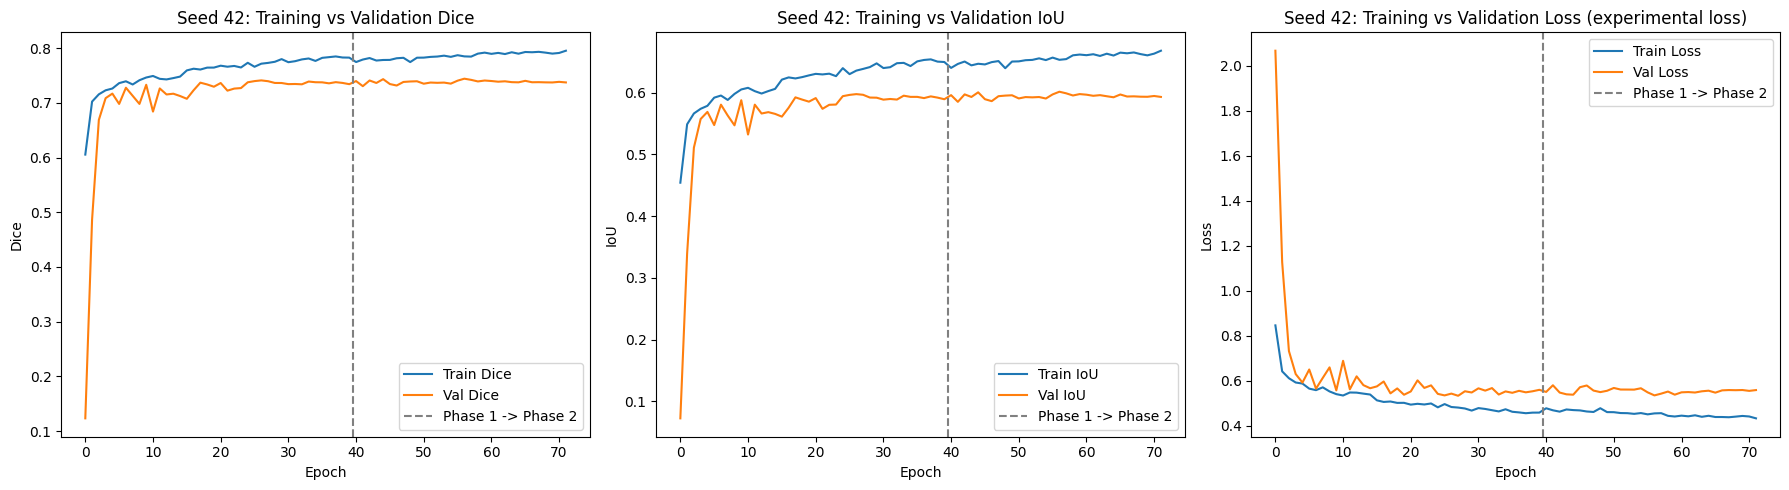

   Saved history plots -> results/experiment_B_loss/seed_42/seed_42_history_plots.png

################################################################################
# EXPERIMENT B - SEED 123
################################################################################

[Seed 123] Building model...
 Backbone trainable: True
 Total backbone layers: 409
 Successfully extracted all encoder features

 Encoder feature channels:
  e1: 16, e2: 40, e3: 56, e4: 136, e5: 1536

 Model created successfully!
   Input shape:  (None, 512, 512, 3)
   Output shape: (None, 512, 512, 1)
   Total params: 68,303,512
   Trainable params: 68,174,840
   MRFM modules: 9 | EdgeAttn: 4 | CoordAttn: 2 | ChanSpatAttn: 3 | Input: (None, 512, 512, 3) | Output: (None, 512, 512, 1)
   ARCHITECTURE UNCHANGED = TRUE
[Seed 123] Class weights (reported, not used directly in loss terms): Background=0.5228, Foreground=11.4485

[Seed 123] PHASE 1: Training decoder (backbone frozen)
Epoch 1/40
139/139 ━━━━━━━━━━━━━━━━━━━

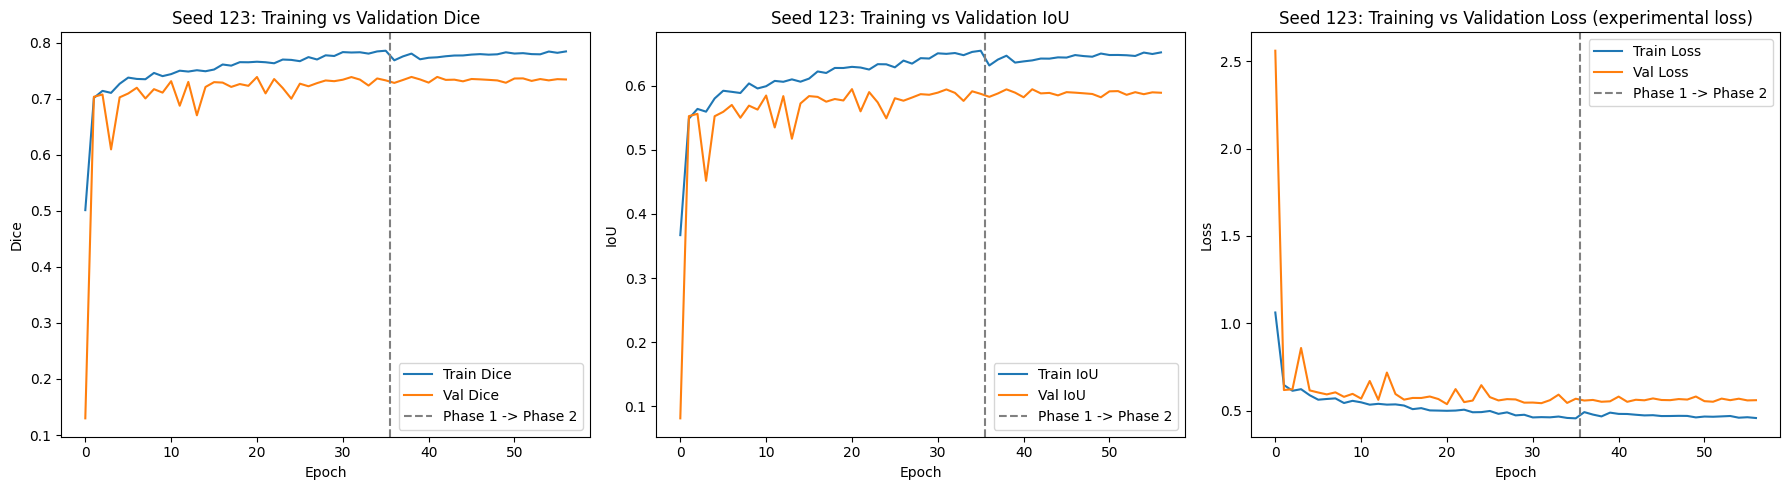

   Saved history plots -> results/experiment_B_loss/seed_123/seed_123_history_plots.png

################################################################################
# EXPERIMENT B - SEED 2024
################################################################################

[Seed 2024] Building model...
 Backbone trainable: True
 Total backbone layers: 409
 Successfully extracted all encoder features

 Encoder feature channels:
  e1: 16, e2: 40, e3: 56, e4: 136, e5: 1536

 Model created successfully!
   Input shape:  (None, 512, 512, 3)
   Output shape: (None, 512, 512, 1)
   Total params: 68,303,512
   Trainable params: 68,174,840
   MRFM modules: 9 | EdgeAttn: 4 | CoordAttn: 2 | ChanSpatAttn: 3 | Input: (None, 512, 512, 3) | Output: (None, 512, 512, 1)
   ARCHITECTURE UNCHANGED = TRUE
[Seed 2024] Class weights (reported, not used directly in loss terms): Background=0.5228, Foreground=11.4485

[Seed 2024] PHASE 1: Training decoder (backbone frozen)
Epoch 1/40
139/139 ━━━━━━━━━━━━━

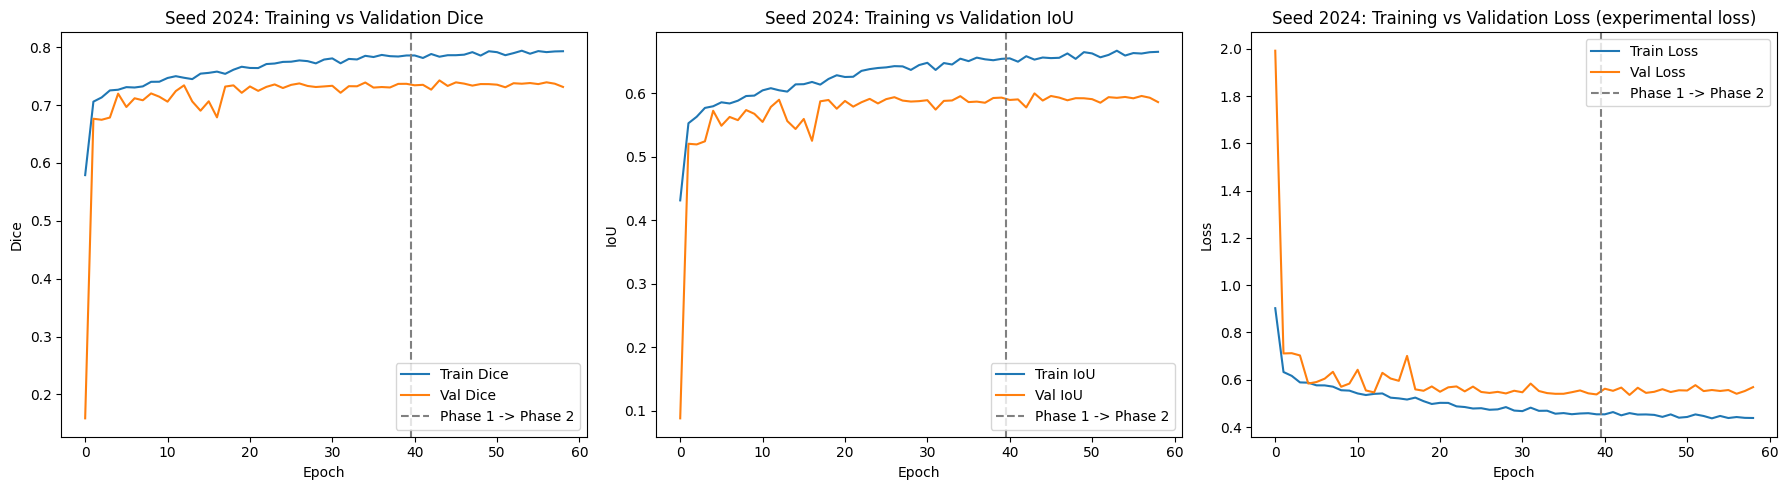

   Saved history plots -> results/experiment_B_loss/seed_2024/seed_2024_history_plots.png

EXPERIMENT B - ALL 3 SEEDS COMPLETE


In [10]:
# ============================================================================
# EXPERIMENT B - MAIN TRAINING LOOP (seeds 42, 123, 2024)
# ----------------------------------------------------------------------------
# For each seed:
#   1. Reseed everything, rebuild the tf.data pipelines (shuffle/augmentation
#      randomness depends on the reseeded global generators).
#   2. Build a FRESH model (architecture unchanged) and run the architecture
#      sanity checks.
#   3. Phase 1 (backbone frozen, Adam 1e-3, 40 epochs max) with the
#      EXPERIMENTAL loss.
#   4. Phase 2 (last 80 backbone layers unfrozen, BN frozen, AdamW 5e-5,
#      weight_decay=1e-5, up to EPOCHS=100) with the SAME experimental loss.
#   5. Reload best checkpoint, tune threshold on VALIDATION ONLY
#      (thresholds = linspace(0.1, 0.7, 13)), freeze it.
#   6. Evaluate TRAIN and TEST with the frozen threshold.
#   7. Save checkpoints/history/plots under results/experiment_B_loss/seed_<seed>/
#      without overwriting any other experiment's checkpoints.
# ============================================================================

MODEL_NAME = "EfficientNetV2-B3 + MRFM + Stage-Adaptive Attention"
EXPERIMENT_NAME = "experiment_B_loss"
BASE_RESULTS_DIR = os.path.join("results", EXPERIMENT_NAME)
os.makedirs(BASE_RESULTS_DIR, exist_ok=True)


def preprocess_test_data(X):
    """Preprocess data the same way as training data (EfficientNetV2 preprocess_input)."""
    return preprocess_input(X * 255.0)


def plot_seed_history(seed, history_phase1, history_phase2, seed_dir):
    """Save Training vs Validation Dice / IoU / Loss plots for one seed."""
    def concat_hist(key):
        h1 = history_phase1.history.get(key, [])
        h2 = history_phase2.history.get(key, [])
        return list(h1) + list(h2)

    train_dice = concat_hist('dice_coefficient')
    val_dice = concat_hist('val_dice_coefficient')
    train_iou = concat_hist('iou_metric')
    val_iou = concat_hist('val_iou_metric')
    train_loss = concat_hist('loss')
    val_loss = concat_hist('val_loss')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(train_dice, label='Train Dice')
    axes[0].plot(val_dice, label='Val Dice')
    axes[0].axvline(len(history_phase1.history.get('loss', [])) - 0.5,
                     color='gray', linestyle='--', label='Phase 1 -> Phase 2')
    axes[0].set_title(f'Seed {seed}: Training vs Validation Dice')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Dice')
    axes[0].legend()

    axes[1].plot(train_iou, label='Train IoU')
    axes[1].plot(val_iou, label='Val IoU')
    axes[1].axvline(len(history_phase1.history.get('loss', [])) - 0.5,
                     color='gray', linestyle='--', label='Phase 1 -> Phase 2')
    axes[1].set_title(f'Seed {seed}: Training vs Validation IoU')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('IoU')
    axes[1].legend()

    axes[2].plot(train_loss, label='Train Loss')
    axes[2].plot(val_loss, label='Val Loss')
    axes[2].axvline(len(history_phase1.history.get('loss', [])) - 0.5,
                     color='gray', linestyle='--', label='Phase 1 -> Phase 2')
    axes[2].set_title(f'Seed {seed}: Training vs Validation Loss (experimental loss)')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].legend()

    plt.tight_layout()
    plot_path = os.path.join(seed_dir, f"seed_{seed}_history_plots.png")
    plt.savefig(plot_path, dpi=150)
    plt.show()
    plt.close(fig)
    print(f"   Saved history plots -> {plot_path}")


all_results_rows = []      # per-seed, per-dataset (Train/Test) metric rows
all_histories = {}         # seed -> combined history dict, for later reuse

for seed in SEEDS:
    print("\n" + "#" * 80)
    print(f"# EXPERIMENT B - SEED {seed}")
    print("#" * 80)

    set_all_seeds(seed)

    seed_dir = os.path.join(BASE_RESULTS_DIR, f"seed_{seed}")
    os.makedirs(seed_dir, exist_ok=True)

    # ------------------------------------------------------------------
    # Rebuild tf.data pipelines fresh for this seed (shuffle/augmentation
    # randomness is drawn from the just-reseeded global generators)
    # ------------------------------------------------------------------
    train_dataset = create_augmented_dataset_with_preprocessing(
        X_train, y_train, batch_size=BATCH_SIZE, augment=True, shuffle=True
    )
    val_dataset = create_augmented_dataset_with_preprocessing(
        X_val, y_val, batch_size=BATCH_SIZE, augment=False, shuffle=False
    )
    test_dataset = create_augmented_dataset_with_preprocessing(
        X_test, y_test, batch_size=BATCH_SIZE, augment=False, shuffle=False
    )

    # ------------------------------------------------------------------
    # Build a fresh model (architecture unchanged) + sanity checks
    # ------------------------------------------------------------------
    print(f"\n[Seed {seed}] Building model...")
    model, backbone = build_efficientnetv2b3_mrfm_attention_unet(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    run_architecture_sanity_checks(model)

    class_weights = calculate_class_weights(y_train)
    print(f"[Seed {seed}] Class weights (reported, not used directly in loss terms): "
          f"Background={class_weights[0]:.4f}, Foreground={class_weights[1]:.4f}")

    # ------------------------------------------------------------------
    # PHASE 1: train decoder (backbone frozen), EXPERIMENTAL loss
    # ------------------------------------------------------------------
    print(f"\n[Seed {seed}] PHASE 1: Training decoder (backbone frozen)")
    backbone.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=experimental_loss,
        metrics=[dice_coefficient, iou_metric]
    )

    phase1_ckpt_path = os.path.join(seed_dir, f"seed_{seed}_phase1.weights.h5")
    callbacks_phase1 = [
        PredictionMonitor(X_val, y_val),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_dice_coefficient',
            patience=15,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_dice_coefficient',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            phase1_ckpt_path,
            monitor='val_dice_coefficient',
            save_best_only=True,
            save_weights_only=True,
            mode='max',
            verbose=1
        )
    ]

    history_phase1 = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=40,
        callbacks=callbacks_phase1,
        verbose=1
    )

    best_dice_phase1 = max(history_phase1.history['val_dice_coefficient'])
    print(f"\n[Seed {seed}] Phase 1 complete - Best Dice: {best_dice_phase1:.4f}")

    # ------------------------------------------------------------------
    # PHASE 2: fine-tune entire model (last 80 backbone layers), SAME
    # experimental loss (never silently reverts to focal_dice_loss)
    # ------------------------------------------------------------------
    print(f"\n[Seed {seed}] PHASE 2: Fine-tuning entire model")
    backbone.trainable = True
    for layer in backbone.layers[:-80]:
        layer.trainable = False

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    optimizer_ft = tf.keras.optimizers.AdamW(
        learning_rate=5e-5,
        weight_decay=1e-5,
        beta_1=0.9,
        beta_2=0.999
    )

    model.compile(
        optimizer=optimizer_ft,
        loss=experimental_loss,
        metrics=[
            dice_coefficient,
            iou_metric,
            'binary_accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    phase2_ckpt_path = os.path.join(seed_dir, f"seed_{seed}_final.weights.h5")
    callbacks_phase2 = [
        PredictionMonitor(X_val, y_val),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_dice_coefficient',
            patience=PATIENCE,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_dice_coefficient',
            factor=0.5,
            patience=8,
            min_lr=1e-7,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            phase2_ckpt_path,
            monitor='val_dice_coefficient',
            save_best_only=True,
            save_weights_only=True,
            mode='max',
            verbose=1
        )
    ]

    history_phase2 = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=callbacks_phase2,
        verbose=1,
        initial_epoch=len(history_phase1.history['loss'])
    )

    best_dice_phase2 = max(history_phase2.history['val_dice_coefficient'])
    best_iou_phase2 = max(history_phase2.history['val_iou_metric'])
    epochs_completed = len(history_phase1.history['loss']) + len(history_phase2.history['loss'])

    print(f"\n[Seed {seed}] Two-phase training complete!")
    print(f"   Best Dice (Phase 2): {best_dice_phase2:.4f}")
    print(f"   Best IoU (Phase 2):  {best_iou_phase2:.4f}")
    print(f"   Total epochs: {epochs_completed}")

    # Explicitly reload best Phase 2 checkpoint for evaluation
    print(f"[Seed {seed}] Loading best Phase 2 weights from checkpoint...")
    model.load_weights(phase2_ckpt_path)

    # ------------------------------------------------------------------
    # THRESHOLD TUNING ON VALIDATION SET ONLY
    # ------------------------------------------------------------------
    print(f"\n[Seed {seed}] Tuning segmentation threshold on validation set...")
    X_val_preprocessed = preprocess_test_data(X_val)
    y_val_pred_soft = model.predict(X_val_preprocessed, batch_size=BATCH_SIZE, verbose=0)

    thresholds = np.linspace(0.1, 0.7, 13)
    best_t, best_val_dice = 0, 0
    for t in thresholds:
        y_val_pred_bin = (y_val_pred_soft > t).astype(np.uint8)
        d = dice_numpy(y_val, y_val_pred_bin)
        if d > best_val_dice:
            best_val_dice = d
            best_t = t

    SEG_THRESHOLD = best_t
    print(f"   Best validation threshold = {SEG_THRESHOLD:.2f} (val Dice = {best_val_dice:.4f}) - FROZEN")

    # ------------------------------------------------------------------
    # TRAIN SET EVALUATION
    # ------------------------------------------------------------------
    X_train_preprocessed = preprocess_test_data(X_train)
    y_train_pred_soft = model.predict(X_train_preprocessed, batch_size=BATCH_SIZE, verbose=0)
    y_train_pred_binary = (y_train_pred_soft > SEG_THRESHOLD).astype(np.uint8)
    y_train_binary = (y_train > 0.5).astype(np.uint8)
    train_metrics = calculate_segmentation_metrics(y_train_binary, y_train_pred_binary)

    print(f"[Seed {seed}] TRAIN  - Dice={train_metrics['dice']:.4f}  "
          f"FG_IoU={train_metrics['iou_foreground']:.4f}  mIoU={train_metrics['miou']:.4f}  "
          f"Precision={train_metrics['precision']:.4f}  Recall={train_metrics['recall']:.4f}")

    # ------------------------------------------------------------------
    # TEST SET EVALUATION
    # ------------------------------------------------------------------
    X_test_preprocessed = preprocess_test_data(X_test)
    y_test_pred_soft = model.predict(X_test_preprocessed, batch_size=BATCH_SIZE, verbose=0)
    y_test_pred_binary = (y_test_pred_soft > SEG_THRESHOLD).astype(np.uint8)
    y_test_binary = (y_test > 0.5).astype(np.uint8)
    test_metrics = calculate_segmentation_metrics(y_test_binary, y_test_pred_binary)

    print(f"[Seed {seed}] TEST   - Dice={test_metrics['dice']:.4f}  "
          f"FG_IoU={test_metrics['iou_foreground']:.4f}  mIoU={test_metrics['miou']:.4f}  "
          f"Precision={test_metrics['precision']:.4f}  Recall={test_metrics['recall']:.4f}")

    # ------------------------------------------------------------------
    # Record per-seed results rows
    # ------------------------------------------------------------------
    for dataset_name, m in [('Train', train_metrics), ('Test', test_metrics)]:
        all_results_rows.append({
            'Seed': seed,
            'Model': MODEL_NAME,
            'Loss': EXPERIMENTAL_LOSS_NAME,
            'Dataset': dataset_name,
            'Dice': m['dice'],
            'Foreground_IoU': m['iou_foreground'],
            'Background_IoU': m['iou_background'],
            'mIoU': m['miou'],
            'Precision': m['precision'],
            'Recall': m['recall'],
            'Threshold': SEG_THRESHOLD
        })

    # ------------------------------------------------------------------
    # Save training history (Phase 1 + Phase 2 concatenated) for this seed
    # ------------------------------------------------------------------
    combined_history = {
        'phase1': history_phase1.history,
        'phase2': history_phase2.history,
    }
    all_histories[seed] = combined_history

    history_json_path = os.path.join(seed_dir, f"seed_{seed}_training_history.json")
    with open(history_json_path, 'w') as f:
        json.dump(
            {k: {kk: [float(v) for v in vv] for kk, vv in v.items()} for k, v in combined_history.items()},
            f, indent=2
        )
    print(f"[Seed {seed}] Saved training history -> {history_json_path}")

    # ------------------------------------------------------------------
    # Save training history plots for this seed
    # ------------------------------------------------------------------
    plot_seed_history(seed, history_phase1, history_phase2, seed_dir)

    # Free memory before next seed
    tf.keras.backend.clear_session()

print("\n" + "=" * 80)
print(f"EXPERIMENT B - ALL {len(SEEDS)} SEEDS COMPLETE")
print("=" * 80)


In [11]:
# ============================================================================
# RESULT FILE: experiment_B_loss_results.csv
# ============================================================================

results_df = pd.DataFrame(all_results_rows, columns=[
    'Seed', 'Model', 'Loss', 'Dataset', 'Dice', 'Foreground_IoU',
    'Background_IoU', 'mIoU', 'Precision', 'Recall', 'Threshold'
])

print("\n" + "=" * 80)
print("EXPERIMENT B - PER-SEED RESULTS")
print("=" * 80)
print(results_df.to_string(index=False))

results_csv_path = "experiment_B_loss_results.csv"
results_df.to_csv(results_csv_path, index=False)
print(f"\n Saved -> {results_csv_path}")



EXPERIMENT B - PER-SEED RESULTS
 Seed                                               Model                                              Loss Dataset     Dice  Foreground_IoU  Background_IoU     mIoU  Precision   Recall  Threshold
   42 EfficientNetV2-B3 + MRFM + Stage-Adaptive Attention Tversky(a=0.3,b=0.7) + Focal(a=0.75,g=2.0) + Dice   Train 0.806265        0.675413        0.983777 0.829595   0.874752 0.747723        0.7
   42 EfficientNetV2-B3 + MRFM + Stage-Adaptive Attention Tversky(a=0.3,b=0.7) + Focal(a=0.75,g=2.0) + Dice    Test 0.793304        0.657419        0.992502 0.824961   0.795345 0.791274        0.7
  123 EfficientNetV2-B3 + MRFM + Stage-Adaptive Attention Tversky(a=0.3,b=0.7) + Focal(a=0.75,g=2.0) + Dice   Train 0.797935        0.663804        0.982843 0.823324   0.852135 0.750218        0.7
  123 EfficientNetV2-B3 + MRFM + Stage-Adaptive Attention Tversky(a=0.3,b=0.7) + Focal(a=0.75,g=2.0) + Dice    Test 0.791590        0.655067        0.992317 0.823692   0.781152 0.

In [12]:
# ============================================================================
# RESULT FILE: experiment_B_loss_summary.csv
# ============================================================================

summary_rows = []
for dataset_name in ['Train', 'Test']:
    subset = results_df[results_df['Dataset'] == dataset_name]
    summary_rows.append({
        'Model': MODEL_NAME,
        'Loss': EXPERIMENTAL_LOSS_NAME,
        'Dataset': dataset_name,
        'Dice_Mean': subset['Dice'].mean(),
        'Dice_STD': subset['Dice'].std(ddof=0),
        'Foreground_IoU_Mean': subset['Foreground_IoU'].mean(),
        'Foreground_IoU_STD': subset['Foreground_IoU'].std(ddof=0),
        'Background_IoU_Mean': subset['Background_IoU'].mean(),
        'Background_IoU_STD': subset['Background_IoU'].std(ddof=0),
        'mIoU_Mean': subset['mIoU'].mean(),
        'mIoU_STD': subset['mIoU'].std(ddof=0),
        'Precision_Mean': subset['Precision'].mean(),
        'Precision_STD': subset['Precision'].std(ddof=0),
        'Recall_Mean': subset['Recall'].mean(),
        'Recall_STD': subset['Recall'].std(ddof=0),
    })

summary_df = pd.DataFrame(summary_rows)

print("\n" + "=" * 80)
print("EXPERIMENT B - 3-SEED SUMMARY (mean ± std)")
print("=" * 80)
print(summary_df.to_string(index=False))

summary_csv_path = "experiment_B_loss_summary.csv"
summary_df.to_csv(summary_csv_path, index=False)
print(f"\n Saved -> {summary_csv_path}")



EXPERIMENT B - 3-SEED SUMMARY (mean ± std)
                                              Model                                              Loss Dataset  Dice_Mean  Dice_STD  Foreground_IoU_Mean  Foreground_IoU_STD  Background_IoU_Mean  Background_IoU_STD  mIoU_Mean  mIoU_STD  Precision_Mean  Precision_STD  Recall_Mean  Recall_STD
EfficientNetV2-B3 + MRFM + Stage-Adaptive Attention Tversky(a=0.3,b=0.7) + Focal(a=0.75,g=2.0) + Dice   Train   0.804963  0.005287             0.673621            0.007393             0.983479            0.000450   0.828550  0.003911        0.862243       0.009388     0.754930     0.00849
EfficientNetV2-B3 + MRFM + Stage-Adaptive Attention Tversky(a=0.3,b=0.7) + Focal(a=0.75,g=2.0) + Dice    Test   0.792540  0.000712             0.656370            0.000977             0.992420            0.000077   0.824395  0.000527        0.788970       0.005883     0.796212     0.00458

 Saved -> experiment_B_loss_summary.csv


In [13]:
# ============================================================================
# COMPARISON: Experimental loss vs. CURRENT PROPOSED MODEL (control loss)
# ----------------------------------------------------------------------------
# Baseline numbers are the frozen 3-seed TEST results reported for the
# current proposed model (EfficientNetV2-B3 + MRFM + Stage-Adaptive
# Attention, control loss = aggressive_imbalance_loss -> focal_dice_loss).
# These are NOT recomputed here; they are the pre-registered comparison
# target for this experiment.
# ============================================================================

BASELINE = {
    'Dice':           (0.7873, 0.0014),
    'Foreground_IoU': (0.6492, 0.0019),
    'mIoU':           (0.8206, 0.0010),
    'Precision':      (0.7581, 0.0072),
    'Recall':         (0.8189, 0.0090),
}
BASELINE_MODEL_LABEL = "Current Proposed Model"
BASELINE_LOSS_LABEL = "Original Loss (aggressive_imbalance_loss -> focal_dice_loss)"

test_summary = summary_df[summary_df['Dataset'] == 'Test'].iloc[0]

comparison_rows = [
    {
        'Model': BASELINE_MODEL_LABEL,
        'Loss': BASELINE_LOSS_LABEL,
        'Dice (mean ± std)': f"{BASELINE['Dice'][0]:.4f} ± {BASELINE['Dice'][1]:.4f}",
        'Foreground IoU (mean ± std)': f"{BASELINE['Foreground_IoU'][0]:.4f} ± {BASELINE['Foreground_IoU'][1]:.4f}",
        'mIoU (mean ± std)': f"{BASELINE['mIoU'][0]:.4f} ± {BASELINE['mIoU'][1]:.4f}",
        'Precision (mean ± std)': f"{BASELINE['Precision'][0]:.4f} ± {BASELINE['Precision'][1]:.4f}",
        'Recall (mean ± std)': f"{BASELINE['Recall'][0]:.4f} ± {BASELINE['Recall'][1]:.4f}",
    },
    {
        'Model': "Experimental Model",
        'Loss': "Tversky + Focal + Dice",
        'Dice (mean ± std)': f"{test_summary['Dice_Mean']:.4f} ± {test_summary['Dice_STD']:.4f}",
        'Foreground IoU (mean ± std)': f"{test_summary['Foreground_IoU_Mean']:.4f} ± {test_summary['Foreground_IoU_STD']:.4f}",
        'mIoU (mean ± std)': f"{test_summary['mIoU_Mean']:.4f} ± {test_summary['mIoU_STD']:.4f}",
        'Precision (mean ± std)': f"{test_summary['Precision_Mean']:.4f} ± {test_summary['Precision_STD']:.4f}",
        'Recall (mean ± std)': f"{test_summary['Recall_Mean']:.4f} ± {test_summary['Recall_STD']:.4f}",
    },
]

comparison_df = pd.DataFrame(comparison_rows)

print("\n" + "=" * 100)
print("FINAL COMPARISON TABLE (TEST SET)")
print("=" * 100)
print(comparison_df.to_string(index=False))

# ----------------------------------------------------------------------
# Deltas (New - Current) and percentage-point improvement
# ----------------------------------------------------------------------
delta_dice = test_summary['Dice_Mean'] - BASELINE['Dice'][0]
delta_fg_iou = test_summary['Foreground_IoU_Mean'] - BASELINE['Foreground_IoU'][0]
delta_miou = test_summary['mIoU_Mean'] - BASELINE['mIoU'][0]
delta_precision = test_summary['Precision_Mean'] - BASELINE['Precision'][0]
delta_recall = test_summary['Recall_Mean'] - BASELINE['Recall'][0]

print("\n" + "=" * 100)
print("Δ (New mean - Current mean), in absolute terms and percentage points (pp)")
print("=" * 100)
print(f"Δ Dice           = {delta_dice:+.4f}  ({delta_dice*100:+.2f} pp)")
print(f"Δ Foreground IoU = {delta_fg_iou:+.4f}  ({delta_fg_iou*100:+.2f} pp)")
print(f"Δ mIoU           = {delta_miou:+.4f}  ({delta_miou*100:+.2f} pp)")
print(f"Δ Precision      = {delta_precision:+.4f}  ({delta_precision*100:+.2f} pp)")
print(f"Δ Recall         = {delta_recall:+.4f}  ({delta_recall*100:+.2f} pp)")



FINAL COMPARISON TABLE (TEST SET)
                 Model                                                         Loss Dice (mean ± std) Foreground IoU (mean ± std) mIoU (mean ± std) Precision (mean ± std) Recall (mean ± std)
Current Proposed Model Original Loss (aggressive_imbalance_loss -> focal_dice_loss)   0.7873 ± 0.0014             0.6492 ± 0.0019   0.8206 ± 0.0010        0.7581 ± 0.0072     0.8189 ± 0.0090
    Experimental Model                                       Tversky + Focal + Dice   0.7925 ± 0.0007             0.6564 ± 0.0010   0.8244 ± 0.0005        0.7890 ± 0.0059     0.7962 ± 0.0046

Δ (New mean - Current mean), in absolute terms and percentage points (pp)
Δ Dice           = +0.0052  (+0.52 pp)
Δ Foreground IoU = +0.0072  (+0.72 pp)
Δ mIoU           = +0.0038  (+0.38 pp)
Δ Precision      = +0.0309  (+3.09 pp)
Δ Recall         = -0.0227  (-2.27 pp)


In [14]:
# ============================================================================
# FINAL INTERPRETATION
# ----------------------------------------------------------------------------
# Primary success criterion: TEST DICE (per the experiment protocol). Do NOT
# declare success merely because recall increases; Dice is the deciding
# metric, with Foreground IoU / mIoU / Precision / Recall as secondary
# context. The test set is used ONLY to report these numbers - it was never
# used to select the threshold or tune the loss weights.
#
# Decision rule (stated explicitly, not tuned post-hoc):
#   - "meaningful" requires |Δ Dice| to clear a margin well above the
#     baseline's own seed-to-seed noise (baseline Dice std = 0.0014), so a
#     0.005 (0.5 percentage point) threshold is used.
#   - "consistent" requires the improvement/degradation to hold for every
#     individual seed's TEST Dice, not just the 3-seed mean.
# ============================================================================

MEANINGFUL_DICE_MARGIN = 0.005  # 0.5 percentage points

per_seed_test_dice = results_df[results_df['Dataset'] == 'Test'].sort_values('Seed')['Dice'].tolist()
baseline_dice_mean = BASELINE['Dice'][0]

all_seeds_above_baseline = all(d > baseline_dice_mean for d in per_seed_test_dice)
all_seeds_below_baseline = all(d < baseline_dice_mean for d in per_seed_test_dice)

print("\n" + "=" * 80)
print("FINAL INTERPRETATION")
print("=" * 80)
print(f"Per-seed TEST Dice: {[f'{d:.4f}' for d in per_seed_test_dice]}")
print(f"Baseline (control loss) TEST Dice mean: {baseline_dice_mean:.4f}")
print(f"Experimental TEST Dice mean:            {test_summary['Dice_Mean']:.4f}")
print(f"Δ Dice: {delta_dice:+.4f} ({delta_dice*100:+.2f} pp)  |  "
      f"meaningful margin = ±{MEANINGFUL_DICE_MARGIN:.4f} ({MEANINGFUL_DICE_MARGIN*100:.2f} pp)")
print(f"All seeds above baseline: {all_seeds_above_baseline}  |  "
      f"All seeds below baseline: {all_seeds_below_baseline}")

if delta_dice > MEANINGFUL_DICE_MARGIN and all_seeds_above_baseline:
    verdict = "LOSS IMPROVES PERFORMANCE"
elif delta_dice < -MEANINGFUL_DICE_MARGIN and all_seeds_below_baseline:
    verdict = "LOSS DEGRADES PERFORMANCE"
else:
    verdict = "LOSS PRODUCES NO MEANINGFUL IMPROVEMENT"

print(f"\n\"{verdict}\"")

print("\nNumerical differences (New - Current):")
print(f"  Δ Dice           = {delta_dice:+.4f}  ({delta_dice*100:+.2f} pp)")
print(f"  Δ Foreground IoU = {delta_fg_iou:+.4f}  ({delta_fg_iou*100:+.2f} pp)")
print(f"  Δ mIoU           = {delta_miou:+.4f}  ({delta_miou*100:+.2f} pp)")
print(f"  Δ Precision      = {delta_precision:+.4f}  ({delta_precision*100:+.2f} pp)")
print(f"  Δ Recall         = {delta_recall:+.4f}  ({delta_recall*100:+.2f} pp)")

if delta_recall > 0 and delta_dice <= MEANINGFUL_DICE_MARGIN:
    print("\nNote: recall increased but this is NOT being counted as an improvement, "
          "since the primary metric (Dice) did not show a meaningful, consistent gain.")

print("\n" + "=" * 80)
print("EXPERIMENT B — LOSS FUNCTION STUDY COMPLETE")
print("=" * 80)



FINAL INTERPRETATION
Per-seed TEST Dice: ['0.7933', '0.7916', '0.7927']
Baseline (control loss) TEST Dice mean: 0.7873
Experimental TEST Dice mean:            0.7925
Δ Dice: +0.0052 (+0.52 pp)  |  meaningful margin = ±0.0050 (0.50 pp)
All seeds above baseline: True  |  All seeds below baseline: False

"LOSS IMPROVES PERFORMANCE"

Numerical differences (New - Current):
  Δ Dice           = +0.0052  (+0.52 pp)
  Δ Foreground IoU = +0.0072  (+0.72 pp)
  Δ mIoU           = +0.0038  (+0.38 pp)
  Δ Precision      = +0.0309  (+3.09 pp)
  Δ Recall         = -0.0227  (-2.27 pp)

EXPERIMENT B — LOSS FUNCTION STUDY COMPLETE
